During this week you studied many important Machine Learning concepts.

Now it is your turn to apply them on a real dataset.

Your mission is to:

* Explore the dataset

* Build Regression and Classification models

* Evaluate them using the correct metrics

* Analyze the results




# Step 0 – Download the Dataset
We will use the dataset from Kaggle:

Dataset:
https://www.kaggle.com/competitions/home-data-for-ml-course/data

Download:

train.csv

data_description.txt

Then upload train.csv into Colab.

# Step 1 – Import the Required Libraries

Import the libraries needed for:

* data analysis

* visualization

* machine learning



In [21]:
# Step 1 – Import the Required Libraries

# Data Analysis and Manipulation
import pandas as pd # For data manipulation and analysis
import numpy as np  # For numerical operations

# Data Visualization
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations
import seaborn as sns       # For making statistical graphics based on matplotlib
sns.set_style('whitegrid')  # Set a nice style for plots

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split # For splitting data into training and testing sets
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler # For encoding categorical features and scaling numerical features
from sklearn.impute import SimpleImputer # For handling missing values

# Machine Learning - Models (Regression)
from sklearn.linear_model import LinearRegression # A basic linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Regression metrics

# Machine Learning - Models (Classification)
from sklearn.linear_model import LogisticRegression # A basic logistic regression model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score # Classification metrics

# Ignore warnings (optional, good for cleaner output)
import warnings
warnings.filterwarnings('ignore')

# Step 2 – Load the Dataset

Now load the dataset and explore it.

💡 Tasks

* Load train.csv

* Display the first rows

* Display the dataset shape

* Display basic statistics

In [22]:
# Step 2 – Load the Dataset

# Load train.csv
df = pd.read_csv('train.csv')
print("Dataset loaded successfully.")

# Display the first rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Display the dataset shape
print(f"\nDataset shape: {df.shape} (rows, columns)")

# Display basic statistics
print("\nBasic statistics of numerical columns:")
display(df.describe())

Dataset loaded successfully.

First 5 rows of the dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Dataset shape: (1460, 81) (rows, columns)

Basic statistics of numerical columns:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# Step 3 – Understand the Dataset

Before training any model, we must understand their data.

💡 Tasks

* List all columns

* Identify categorical features

* Identify numerical features

In [23]:
# Step 3 – Understand the Dataset

# List all columns
print("\nAll columns in the dataset:")
print(df.columns.tolist())

# Dataset info
print("\nDataset Info (Data Types and Non-Null Counts):")
df.info()

# Identify categorical and numerical features
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include='object').columns.tolist()

print(f"\nNumerical Features ({len(numerical_features)}):\n{numerical_features}")
print(f"\nCategorical Features ({len(categorical_features)}):\n{categorical_features}")

# Cardinality
print("\nCardinality of Categorical Features:")
for col in categorical_features:
    print(f"- {col}: {df[col].nunique()} unique values")


All columns in the dataset:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'Scree

# Step 4 – Missing Values Analysis

Machine learning models cannot handle missing values well.

💡 Task

* Check which columns contain missing values


Missing values per column:


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81



Percentage of missing values per column:


,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageType,5.547945
GarageYrBlt,5.547945
GarageFinish,5.547945


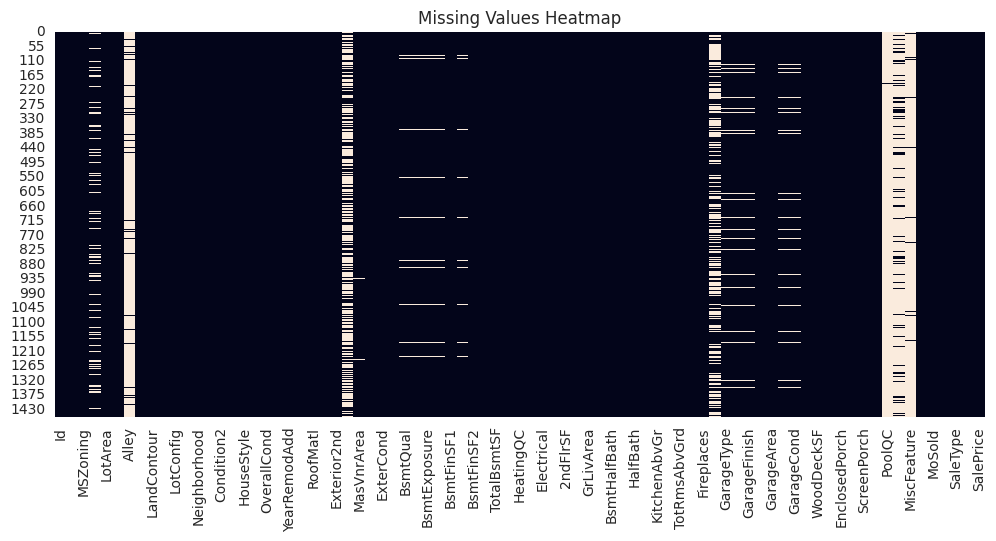

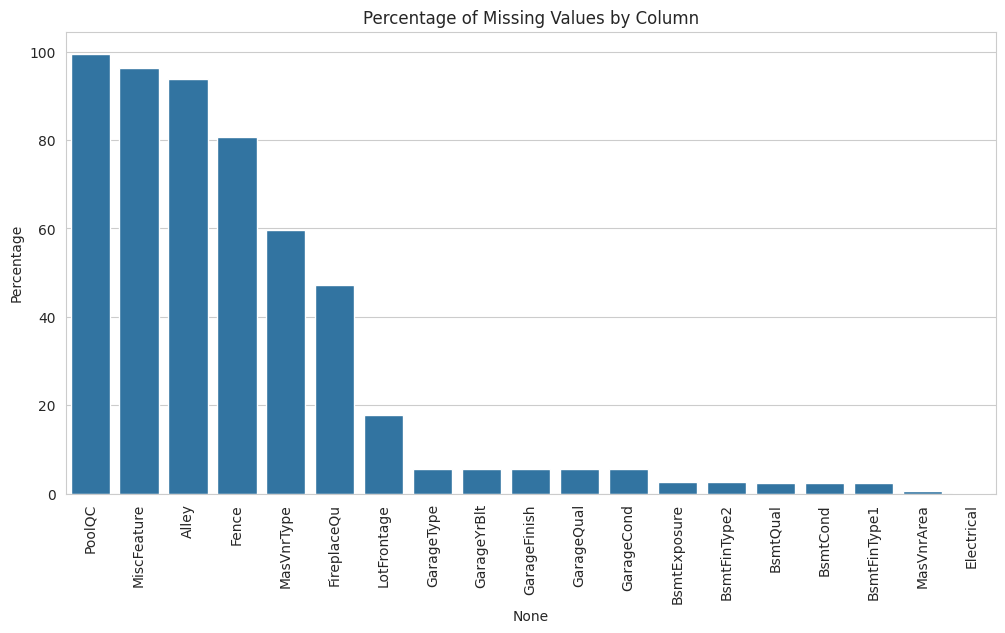

In [24]:
# Step 4 – Missing Values Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Check missing values count
print("\nMissing values per column:")

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if missing_values.empty:
    print("No missing values found.")
else:
    display(missing_values)



# 2. Percentage of missing values

print("\nPercentage of missing values per column:")

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

if missing_percent.empty:
    print("No missing values found.")
else:
    display(missing_percent)

# 3. Visualization - Heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


# 4. Visualization - Bar Plot

if not missing_percent.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_percent.index, y=missing_percent.values)
    plt.xticks(rotation=90)
    plt.ylabel('Percentage')
    plt.title('Percentage of Missing Values by Column')
    plt.show()
else:
    print("No missing values to visualize.")

# Step 5 – Data Cleaning

Now we prepare the data for machine learning.

💡 Tasks

*  Drop unnecessary features
* Create new features if possible

* Handle missing values using the right techniques


In [25]:
# Step 5 – Data Cleaning
# 1. Drop unnecessary features
# Drop 'Id' column
columns_to_drop = ['Id']

# Drop columns with more than 50% missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
high_missing_cols = missing_percent[missing_percent > 50].index.tolist()

columns_to_drop.extend(high_missing_cols)

df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

print(f"Dropped columns: {columns_to_drop}")
print(f"New shape after dropping columns: {df_cleaned.shape}")


# 2. Separate numerical & categorical


numerical_cols = df_cleaned.select_dtypes(include=np.number).columns
categorical_cols = df_cleaned.select_dtypes(include='object').columns

# 3. Handle missing values

# Numerical .. median
for col in numerical_cols:
    if df_cleaned[col].isnull().any():
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Categorical .. mode
for col in categorical_cols:
    if df_cleaned[col].isnull().any():
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])


# 4. Check remaining missing values

print("\nRemaining missing values:")
print(df_cleaned.isnull().sum().sum())  # Should be 0


# 5. Feature Engineering

# Total surface
if set(['1stFlrSF', '2ndFlrSF', 'TotalBsmtSF']).issubset(df_cleaned.columns):
    df_cleaned['TotalSF'] = (
        df_cleaned['1stFlrSF'] +
        df_cleaned['2ndFlrSF'] +
        df_cleaned['TotalBsmtSF']
    )





# Years since remodel
if set(['YrSold', 'YearRemodAdd']).issubset(df_cleaned.columns):
    df_cleaned['YearsRemodel'] = df_cleaned['YrSold'] - df_cleaned['YearRemodAdd']

print("\nData cleaning completed successfully.")

Dropped columns: ['Id', 'Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']
New shape after dropping columns: (1460, 75)

Remaining missing values:
0

Data cleaning completed successfully.


# Step 6 – Encode Categorical Features

Machine learning models work with numbers, not text.

💡 Tasks

Encode categorical features using:

* Label Encoding OR

* One-Hot Encoding

* Choose and research the best option and apply it.

In [26]:
# Step 6 – Encode Categorical Features

# Identify categorical features
categorical_features = df_cleaned.select_dtypes(include='object').columns.tolist()

print("\nApplying One-Hot Encoding...")

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(
    df_cleaned,
    columns=categorical_features,
    drop_first=True
)

# Check result
print(f"Original shape: {df_cleaned.shape}")
print(f"Encoded shape: {df_encoded.shape}")

display(df_encoded.head())


Applying One-Hot Encoding...
Original shape: (1460, 77)
Encoded shape: (1460, 236)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False


# Step 7 – Define Features (X) and Target (Y)

Our target variable will be: **SalePrice**

💡 Tasks

* Define X (features)
* Define y (target)

In [27]:
# Step 7 – Define Features (X) and Target (Y)

# Target variable is SalePrice

# Define features (X)
X = df_encoded.drop('SalePrice', axis=1)

# Define target (y)
y = df_encoded['SalePrice']

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

print("\nX head:")
display(X.head())

print("\ny head:")
display(y.head())

Shape of X (features): (1460, 235)
Shape of y (target): (1460,)

X head:


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False



y head:


,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000


# Step 8 – Train/Test Split

Before training a model we split the dataset. one for the model so it can learn using it and get trained using it and the other to test it and see how our model is really doing!

💡 Tasks

Split the dataset into:

* Training set

* Testing set

In [28]:
# Step 8 – Train/Test Split

# Split dataset into training set and testing set

from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display shapes to confirm split
print("Training set shape:")
print(X_train.shape, y_train.shape)

print("\nTesting set shape:")
print(X_test.shape, y_test.shape)


Training set shape:
(1168, 235) (1168,)

Testing set shape:
(292, 235) (292,)


# Reflection Question

What problem would happen if we trained and evaluated on the same data?

# If we train and evaluate on the same data the model will just memorize the data instead of learning general patterns this leads to overly good results during training but poor performance on new unseen data (overfitting)

# Step 9 – Linear Regression Model

Now we will predict house prices using Linear Regression.

💡 Tasks

* Train a Linear Regression model
* Predict on the test set


Compute the following metrics:

* MAE

* MSE

* R² Score

In [29]:
# Step 9 – Linear Regression Model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Model trained successfully")

# Predict on test set
y_pred_lr = linear_model.predict(X_test)

# Evaluate model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Print results
print("\nModel Evaluation Results:")
print(f"MAE: {mae_lr:.2f}")
print(f"MSE: {mse_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R² Score: {r2_lr:.2f}")

Model trained successfully

Model Evaluation Results:
MAE: 20458.75
MSE: 2738416841.45
RMSE: 52329.88
R² Score: 0.64


# Reflection Question

Based on the metrics:

Are predictions good or weak?

Do you think the model is underfitting or performing well?

Explain.

# The predictions are moderate but not very strong The model explains about 64% of the variance (R² = 0.64) which means it captures some patterns but still misses a lot
# Overall it is slightly underfitting or only partially performing well since the error values are still relatively high and the model is too simple to fully capture the complexity of house prices

# Step 10 – Create a Classification Problem

Now we will transform this dataset into a classification task.

Create a new target:
**Expensive_House**

Rules:

1 → house price above median

0 → house price below median

💡 Tasks

Create the new binary target
Train a Logistic Regression model





In [30]:
# Step 10 – Create a Classification Problem

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Create binary target based on median
median_saleprice = y.median()

print(f"Median SalePrice: {median_saleprice:.2f}")

y_classification = (y > median_saleprice).astype(int)

# Split dataset for classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

print("Class distribution in training set:")
print(y_train_cls.value_counts())

# Train Logistic Regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear')
logistic_model.fit(X_train_cls, y_train_cls)

print("\nModel trained successfully")

# Predictions
y_pred_cls = logistic_model.predict(X_test_cls)
y_pred_proba_cls = logistic_model.predict_proba(X_test_cls)[:, 1]

Median SalePrice: 163000.00
Class distribution in training set:
SalePrice
0    586
1    582
Name: count, dtype: int64

Model trained successfully


# Step 11 – Model Evaluation

Evaluate the classification model.

💡 Tasks

Generate:

* Confusion Matrix

* Accuracy

* Precision

* Recall

In [31]:
# Step 11 – Model Evaluation

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

print("Logistic Regression Model Evaluation")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_cls, y_pred_cls)

print("\nConfusion Matrix:")
display(pd.DataFrame(
    conf_matrix,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

# Accuracy
accuracy = accuracy_score(y_test_cls, y_pred_cls)
print(f"Accuracy: {accuracy:.2f}")

# Precision
precision = precision_score(y_test_cls, y_pred_cls)
print(f"Precision: {precision:.2f}")

# Recall
recall = recall_score(y_test_cls, y_pred_cls)
print(f"Recall: {recall:.2f}")

# F1 Score
f1 = f1_score(y_test_cls, y_pred_cls)
print(f"F1 Score: {f1:.2f}")

Logistic Regression Model Evaluation

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,134,12
Actual 1,10,136


Accuracy: 0.92
Precision: 0.92
Recall: 0.93
F1 Score: 0.93


# Step 12 – ROC Curve & AUC

Now evaluate using ROC Curve.

💡 Tasks

* Plot the ROC Curve
* Calculate AUC score

AUC Score: 0.98


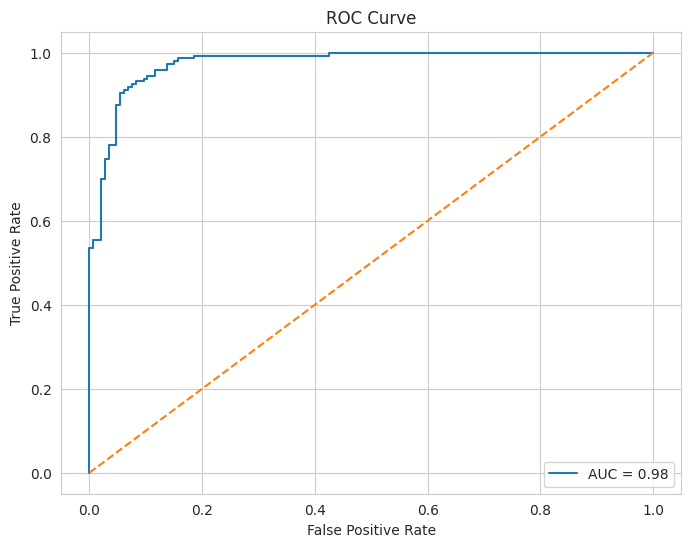

In [32]:
# Step 12 – ROC Curve & AUC

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities for positive class
y_pred_proba = y_pred_proba_cls

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test_cls, y_pred_proba)

# Compute AUC score
auc_score = roc_auc_score(y_test_cls, y_pred_proba)

print(f"AUC Score: {auc_score:.2f}")

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Reflection Questions

If Recall is high but Precision is low, what does it mean?

# If recall is high but precision is low it means the model is correctly finding most of the positive cases but it also includes many false positives in other words it detects almost everything positive but not all of its positive predictions are correct

# Step 13 – Bias vs Variance Analysis

Compare:

* Training score

* Testing score

💡 Tasks

Calculate training accuracy and testing accuracy.

In [33]:
# Step 13 – Bias vs Variance Analysis

from sklearn.metrics import accuracy_score

# Training accuracy
y_train_pred = logistic_model.predict(X_train_cls)
train_accuracy = accuracy_score(y_train_cls, y_train_pred)

# Testing accuracy
test_accuracy = accuracy_score(y_test_cls, y_pred_cls)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

Training Accuracy: 0.95
Testing Accuracy: 0.92


Based on the results:

Is the model:

* Overfitting

* Underfitting

* Balanced

Explain using Bias–Variance intuition.

#The model appears to be balanced because the training and testing accuracies are close this means it learned the patterns well without memorizing the data (no overfitting) and still performs well on unseen data (no underfitting)

# Final Conclusion (Max 10 lines)

Write a short summary explaining:

* What you learned from this challenge

* The biggest difficulty you faced

* What you would improve in the model